Дорогой студент!

В данном домашнем задании предоставляется возможность поработать с задачей по распознаванию позитивных и негативных отзывы людей по автомобилю Tesla. База для обучения содержит два текстовых файла с рядом строчных отзывов с мнением людей об автомобиле Tesla, соответственно негативного и позитивного содержания. Ссылка на скачивание базы уже включена в ноутбук задания.


Необходимо выполнить следующие действия:

  1. Загрузите саму базу по ссылке и подговьте файлы базы для обработки.
  2. Создайте обучающую и проверочную выборки, обратив особое внимание на балансировку базы: количество примеров каждого класса должно быть примерно одного порядка.
  3. Подготовьте выборки для обучения и обучите сеть. Добейтесь результата точности сети в 85-90% на проверочной выборке.
   


**Импорт библиотек, загрузка базы и подготовка её к предобработке.**

In [ ]:
# Работа с массивами данных
import numpy as np

# Работа с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Заполнение последовательностей до определенной длины
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Загрузка датасетов из облака google
import gdown

# Для работы с файлами в Colaboratory
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/tesla.zip', None, quiet=True)

'tesla.zip'

**Деление общей базы отзывов на данные для обучения и проверки.**

In [ ]:
# Распаковка архива в папку writers
!unzip -qo tesla.zip -d tesla/

# Просмотр содержимого папки
!ls tesla

'Негативный отзыв.txt'	'Позитивный отзыв.txt'


**Загрузка текста из файлов, преобразование в одну строку.**

In [ ]:
# Объявляем функции для чтения файла. На вход отправляем путь к файлу
def read_text(file_name):

  # Задаем открытие нужного файла в режиме чтения
  read_file = open(file_name, 'r')

  # Читаем текст
  text = read_file.read()

  # Переносы строки переводим в пробелы
  text = text.replace("\n", " ")

  # Возвращаем текст файла
  return text

# Объявляем интересующие нас классы
class_names = ["Негативный отзыв", "Позитивный отзыв"]

# Считаем количество классов
num_classes = len(class_names)

**Тексты в один список.**

In [ ]:
import os
# Создаём список под тексты для обучающей выборки
texts_list = []

# Циклом проводим итерацию по текстовым файлам в папке отзывов
for j in os.listdir('/content/tesla/'):

  # Добавляем каждый файл в общий список для выборки
        texts_list.append(read_text('/content/tesla/' + j))

        # Выводим на экран сообщение о добавлении файла
        print(j, 'добавлен в обучающую выборку')

Позитивный отзыв.txt добавлен в обучающую выборку
Негативный отзыв.txt добавлен в обучающую выборку


In [ ]:
# Узнаем объём каждого текста в словах и символах
texts_len = [len(text) for text in texts_list]

# Устанавливаем "счётчик" номера текста
t_num = 0

# Выводим на экран  информационное сообщение
print(f'Размеры текстов по порядку (в токенах):')

# Циклом проводим итерацию по списку с объёмами текстов
for text_len in texts_len:

  # Запускаем "счётчик" номера текста
  t_num += 1

  # Выводим на экран сообщение о номере и объёме текста
  print(f'Текст №{t_num}: {text_len}')

Размеры текстов по порядку (в токенах):
Текст №1: 213381
Текст №2: 134535


Далее рассчитаем, сколько символов составит 80% объёма каждого текста, чтобы по полученному индексу отделить эти 80% на обучающую и оставшиеся 20% на проверочную выборку. Эти значения необходимы для подготовки деления на выборки слайсингом по индексу.

In [ ]:
# Создаём список с вложенным циклом по длинам текстов, где i - 100% текста, i/5 - 20% текста
train_len_shares = [(i - round(i/5)) for i in texts_len]

# Устанавливаем "счётчик" номера текста
t_num = 0

# Циклом проводим итерацию по списку с объёмами текстов равными 80% от исходных
for train_len_share in train_len_shares:

  # Запускаем "счётчик" номера текста
  t_num += 1

  # Выводим на экран сообщение о номере и объёме текста в 80% от исходного
  print(f'Доля 80% от текста №{t_num}: {train_len_share} символов')

Доля 80% от текста №1: 170705 символов
Доля 80% от текста №2: 107628 символов


In [ ]:
train_texts = []
test_texts = []

for i in range(len(texts_list)):
    train_part = texts_list[i][:train_len_shares[i]] # выделяем трэйн часть
    test_part  = texts_list[i][train_len_shares[i]:] # выделяем тест часть

    train_texts.append(train_part)
    test_texts.append(test_part)


Превращаем текст  в список окон (фрагментов), каждое окно длиной = win_size слов а сдвиг = step слов

In [ ]:
def split_text(text, win_size=100, step=20):
    words = text.split()
    return [
        ' '.join(words[i:i+win_size])
        for i in range(0, len(words)-win_size, step)
    ]

 Формируем датасет: для каждого класса разбиваем тексты на фрагменты (окна) и добавляем их в train/val вместе с соответствующими метками класса

In [ ]:
x_train = []
y_train = []

x_val = []
y_val = []

for cls in range(num_classes):
    # train
    chunks = split_text(train_texts[cls])
    x_train += chunks
    y_train += [cls] * len(chunks)

    # test
    chunks = split_text(test_texts[cls])
    x_val += chunks
    y_val += [cls] * len(chunks)

In [ ]:
print(np.bincount(y_train))

[1287  833]


Обрезаем большие классы до размера самого маленького, чтобы убрать дисбаланс

In [ ]:
min_count = min(np.bincount(y_train))

balanced_x = []
balanced_y = []

for cls in range(num_classes):
    cls_x = [x for x, y in zip(x_train, y_train) if y == cls][:min_count]
    balanced_x += cls_x
    balanced_y += [cls]*len(cls_x)

x_train = balanced_x
y_train = balanced_y

Преобразуем тексты в числовое представление: строим словарь по train (до VOCAB_SIZE) и кодируем тексты в матрицы признаков

In [ ]:
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='UNK')
tokenizer.fit_on_texts(x_train)

x_train = tokenizer.texts_to_matrix(x_train)
x_val  = tokenizer.texts_to_matrix(x_val)

In [ ]:
y_train = utils.to_categorical(y_train, num_classes)
y_val  = utils.to_categorical(y_val, num_classes)

In [ ]:
model = Sequential()

model.add(Dense(128, input_dim=VOCAB_SIZE, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=6,
    batch_size=32,
    validation_data=(x_val, y_val)
)

Epoch 1/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8920 - loss: 0.2712 - val_accuracy: 0.8675 - val_loss: 0.3533
Epoch 2/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8619 - val_loss: 0.3710
Epoch 3/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 1.0000 - loss: 3.8118e-04 - val_accuracy: 0.8638 - val_loss: 0.3709
Epoch 4/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 2.9675e-04 - val_accuracy: 0.8638 - val_loss: 0.3842
Epoch 5/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 1.6975e-04 - val_accuracy: 0.8619 - val_loss: 0.3877
Epoch 6/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 1.1086e-04 - val_accuracy: 0.8657 - val_loss: 0.4006


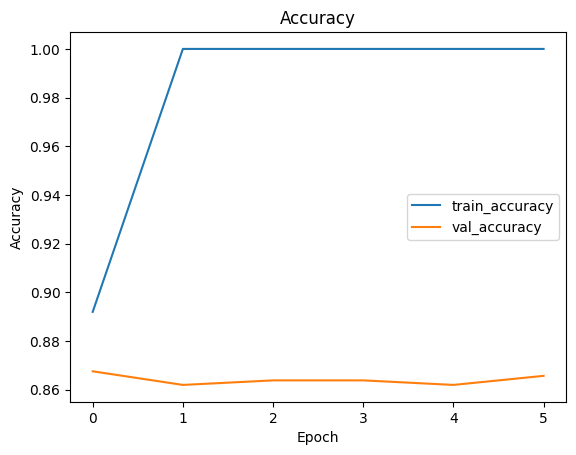

In [ ]:
plt.figure()

plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')

plt.legend()
plt.show()

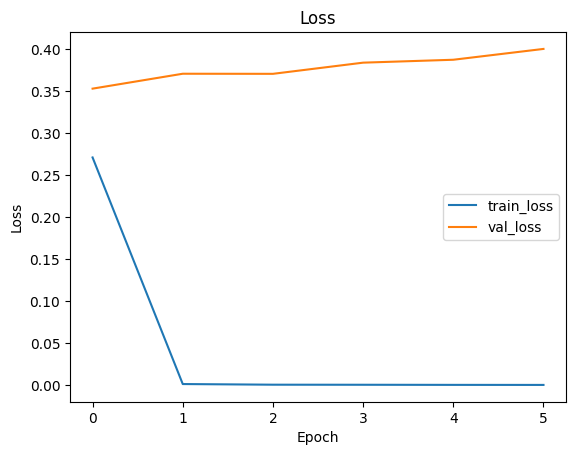

In [ ]:
plt.figure()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')

plt.legend()
plt.show()